# **Notebook 1: Data Ingestion & Storage Design**
**Dataset**: HDFS_ML_Dataset.csv (~1.7 GB, ~3.45M rows, 81 features) | **Task**: Binary Classification – HDFS Anomaly Detection

## **1. SparkSession Configuration**

In [1]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, DoubleType, IntegerType, StringType
)

spark = (
    SparkSession.builder
    .appName("HDFS_Anomaly_Detection_Ingestion")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.executor.cores", "2")
    .config("spark.dynamicAllocation.enabled", "true")
    .config("spark.dynamicAllocation.minExecutors", "1")
    .config("spark.dynamicAllocation.maxExecutors", "4")
    .config("spark.dynamicAllocation.initialExecutors", "2")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.default.parallelism", "8")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryoserializer.buffer.max", "512m")
    .config("spark.sql.autoBroadcastJoinThreshold", str(10 * 1024 * 1024))
    .config("spark.sql.parquet.filterPushdown", "true")
    .config("spark.sql.parquet.mergeSchema", "false")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.adaptive.skewJoin.enabled", "true")
    .config("spark.ui.port", "4040")
    .config("spark.eventLog.enabled", "false")
    .master("local[*]")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version : {spark.version}")
print(f"App name      : {spark.sparkContext.appName}")
print(f"Master        : {spark.sparkContext.master}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/28 15:47:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/28 15:47:10 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/02/28 15:47:10 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/02/28 15:47:10 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/02/28 15:47:10 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


Spark version : 3.5.0
App name      : HDFS_Anomaly_Detection_Ingestion
Master        : local[*]


## **2. Schema Definition**

In [2]:
event_fields = [StructField(f"E{i}", DoubleType(), True) for i in range(1, 30)]

label_field = [StructField("Label", IntegerType(), True)]

stat_fields = [
    StructField("total_events",         DoubleType(), True),
    StructField("mean_event_count",     DoubleType(), True),
    StructField("std_event_count",      DoubleType(), True),
    StructField("max_event_count",      DoubleType(), True),
    StructField("min_event_count",      DoubleType(), True),
    StructField("nonzero_events",       DoubleType(), True),
    StructField("event_sparsity",       DoubleType(), True),
    StructField("event_concentration",  DoubleType(), True),
    StructField("event_balance",        DoubleType(), True),
]

top_events = [5, 26, 11, 9, 21, 23]
interaction_fields = []
for i in range(len(top_events)):
    for j in range(i + 1, len(top_events)):
        a, b = top_events[i], top_events[j]
        interaction_fields.append(StructField(f"E{a}_E{b}_interaction", DoubleType(), True))
        interaction_fields.append(StructField(f"E{a}_E{b}_ratio",       DoubleType(), True))

poly_events = [5, 26, 11, 9]
poly_fields = []
for e in poly_events:
    poly_fields += [
        StructField(f"E{e}_squared", DoubleType(), True),
        StructField(f"E{e}_cubed",   DoubleType(), True),
        StructField(f"E{e}_log",     DoubleType(), True),
    ]

SCHEMA = StructType(event_fields + label_field + stat_fields + interaction_fields + poly_fields)

print(f"Total schema columns : {len(SCHEMA.fields)}")
for f in SCHEMA.fields[:10]:
    print(f"  {f.name:35s}  {f.dataType}")
print("  ...")

Total schema columns : 81
  E1                                   DoubleType()
  E2                                   DoubleType()
  E3                                   DoubleType()
  E4                                   DoubleType()
  E5                                   DoubleType()
  E6                                   DoubleType()
  E7                                   DoubleType()
  E8                                   DoubleType()
  E9                                   DoubleType()
  E10                                  DoubleType()
  ...


## **3. Data Ingestion with Validation**

In [3]:
import os

BASE_DIR    = "/home/sayan/Lakhveer"
CSV_PATH    = os.path.join(BASE_DIR, "HDFS_ML_Dataset.csv")
PARQUET_DIR = os.path.join(BASE_DIR, "project", "data", "hdfs_parquet")
SAMPLE_DIR  = os.path.join(BASE_DIR, "project", "data", "samples")

t0 = time.time()

raw_df = (
    spark.read
    .option("header",      "true")
    .option("inferSchema", "false")
    .option("mode",        "DROPMALFORMED")
    .option("nullValue",   "null")
    .option("nanValue",    "NaN")
    .schema(SCHEMA)
    .csv(CSV_PATH)
)

raw_df = raw_df.withColumn("ingestion_ts", F.current_timestamp())

elapsed = time.time() - t0
print(f"CSV read plan built in {elapsed:.2f}s  (lazy)")
print(f"Partitions after read : {raw_df.rdd.getNumPartitions()}")

CSV read plan built in 1.60s  (lazy)
Partitions after read : 13


In [4]:
t0 = time.time()
total_rows = raw_df.count()
print(f"Total rows ingested : {total_rows:,}  ({time.time()-t0:.1f}s)")
print(f"Total columns       : {len(raw_df.columns)}")

print("\nNull counts on critical columns:")
key_cols = [f"E{i}" for i in range(1, 10)] + ["Label", "total_events", "mean_event_count"]
null_counts = raw_df.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in key_cols]
).collect()[0].asDict()
for col, cnt in null_counts.items():
    status = "✓" if cnt == 0 else "✗ WARN"
    print(f"  {status}  {col:30s}: {cnt}")

Total rows ingested : 3,450,366  (2.6s)
Total columns       : 82

Null counts on critical columns:


  ✓  E1                            : 0
  ✓  E2                            : 0
  ✓  E3                            : 0
  ✓  E4                            : 0
  ✓  E5                            : 0
  ✓  E6                            : 0
  ✓  E7                            : 0
  ✓  E8                            : 0
  ✓  E9                            : 0
  ✓  Label                         : 0
  ✓  total_events                  : 0
  ✓  mean_event_count              : 0


In [5]:
print("Label distribution:")
label_dist = (
    raw_df.groupBy("Label")
    .count()
    .withColumn("pct", F.round(F.col("count") / total_rows * 100, 2))
    .orderBy("Label")
)
label_dist.show()

dist          = {row["Label"]: row["count"] for row in label_dist.collect()}
n_normal      = dist.get(0, 0)
n_anomaly     = dist.get(1, 0)
imbalance_ratio = n_normal / max(n_anomaly, 1)
print(f"Class imbalance ratio (normal:anomaly) = {imbalance_ratio:.1f}:1")

Label distribution:


+-----+-------+-----+
|Label|  count|  pct|
+-----+-------+-----+
|    0|3349338|97.07|
|    1| 101028| 2.93|
+-----+-------+-----+



Class imbalance ratio (normal:anomaly) = 33.2:1


## **4. Exploratory Data Analysis (EDA)**

In [6]:
event_cols = [f"E{i}" for i in range(1, 30)]
print("Event feature statistics (sample):")
raw_df.select(event_cols[:10]).describe().show(truncate=False)

Event feature statistics (sample):


26/02/28 15:47:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+--------------------+-------------------+------------------+------------------+-----------------+-------------------+-------------------+-------------------+------------------+-------------------+
|summary|E1                  |E2                 |E3                |E4                |E5               |E6                 |E7                 |E8                 |E9                |E10                |
+-------+--------------------+-------------------+------------------+------------------+-----------------+-------------------+-------------------+-------------------+------------------+-------------------+
|count  |3450366             |3450366            |3450366           |3450366           |3450366          |3450366            |3450366            |3450366            |3450366           |3450366            |
|mean   |0.039831194719635275|0.24272140984445612|0.7757928579177735|0.6501246244603999|2.996628401152207|0.05162316113711869|0.04534655164119474|0.03970204900002166|2.96800459

In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import pandas as pd
import numpy as np

SAMPLE_FRAC = 0.02
sample_pd = raw_df.sample(fraction=SAMPLE_FRAC, seed=42).toPandas()
print(f"Sampled {len(sample_pd):,} rows for visualisation")

Sampled 69,123 rows for visualisation


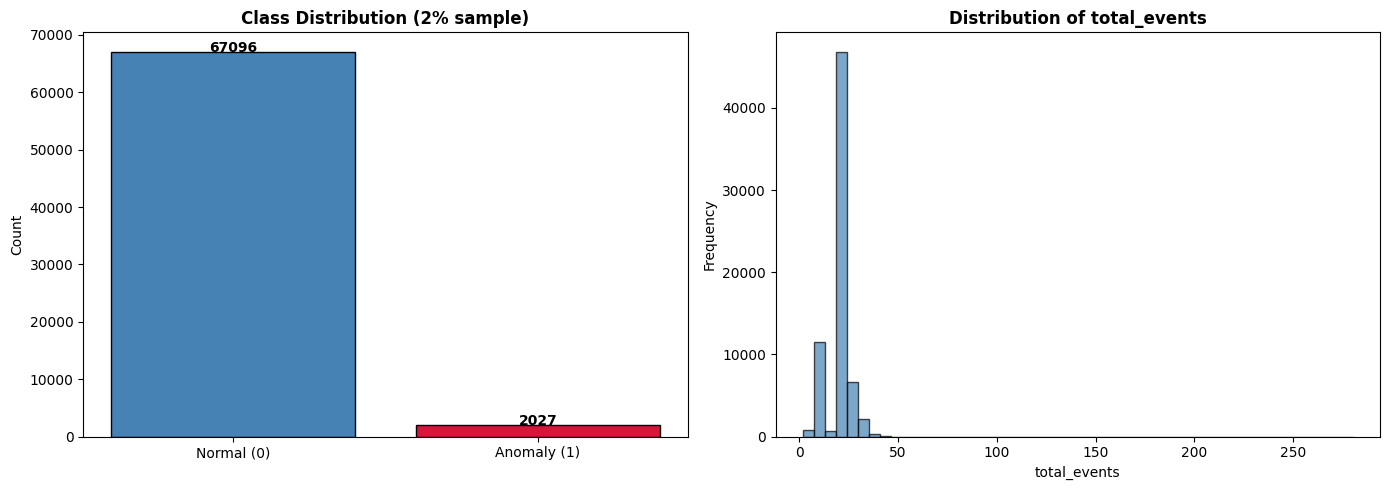

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = sample_pd['Label'].value_counts()
axes[0].bar(['Normal (0)', 'Anomaly (1)'], [counts.get(0, 0), counts.get(1, 0)],
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution (2% sample)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].hist(sample_pd['total_events'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of total_events', fontweight='bold')
axes[1].set_xlabel('total_events')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'project/data/samples/eda_class_distribution.png'), bbox_inches='tight')
plt.show()

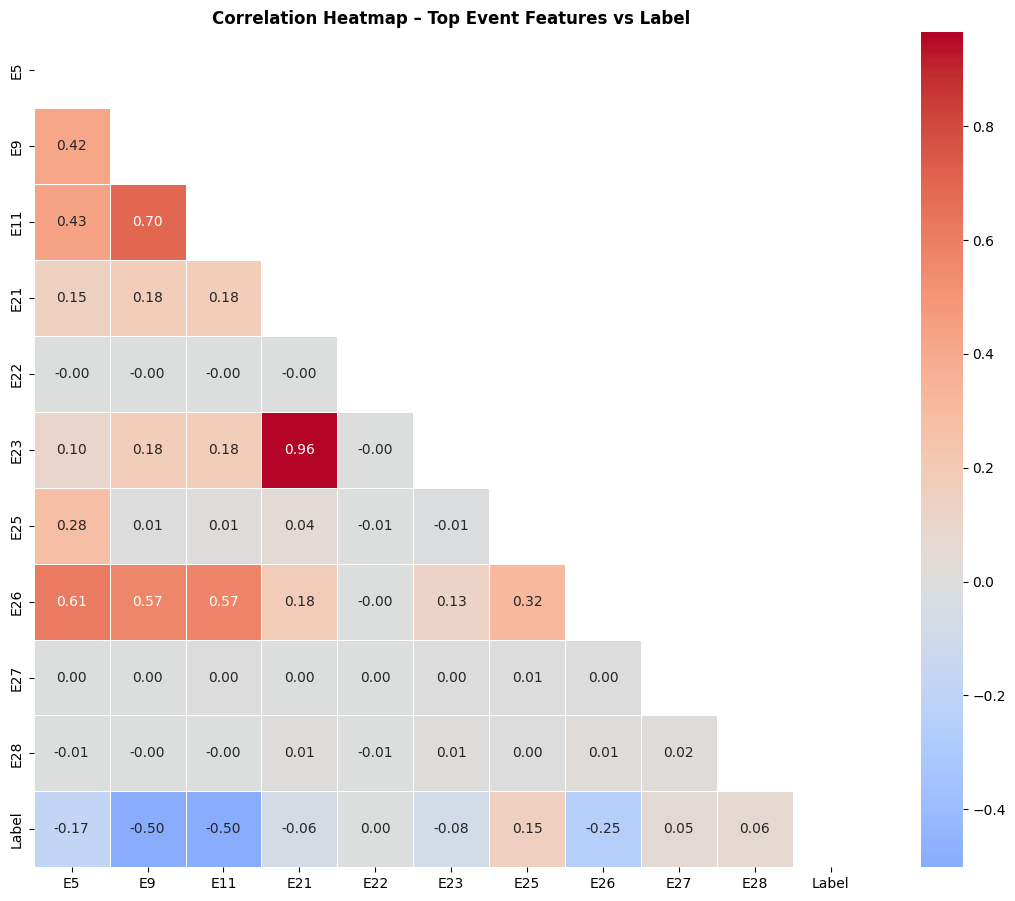

In [9]:
import seaborn as sns

top_event_cols = [f"E{i}" for i in [5, 9, 11, 21, 22, 23, 25, 26, 27, 28]] + ['Label']
corr_matrix = sample_pd[top_event_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            square=True, ax=ax)
ax.set_title('Correlation Heatmap – Top Event Features vs Label', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'project/data/samples/eda_correlation_heatmap.png'), bbox_inches='tight')
plt.show()

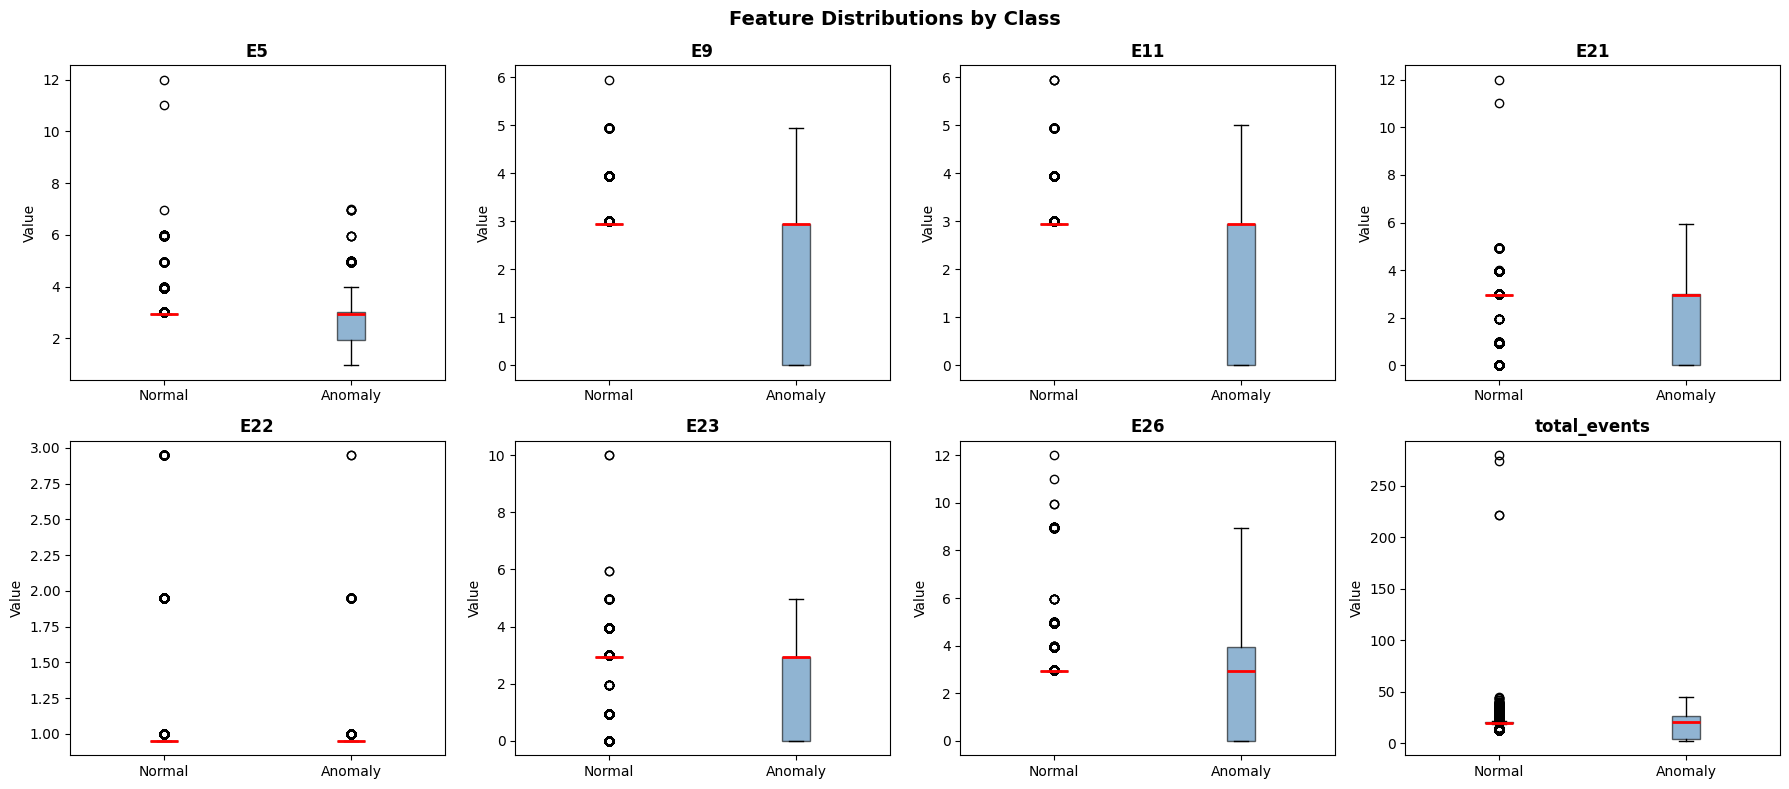

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
feat_subset = ['E5', 'E9', 'E11', 'E21', 'E22', 'E23', 'E26', 'total_events']

for ax, feat in zip(axes.ravel(), feat_subset):
    data_0 = sample_pd[sample_pd['Label'] == 0][feat]
    data_1 = sample_pd[sample_pd['Label'] == 1][feat]
    ax.boxplot([data_0, data_1], labels=['Normal', 'Anomaly'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'project/data/samples/eda_boxplots.png'), bbox_inches='tight')
plt.show()

## **5. Partitioning Strategy & Parquet Storage**

In [11]:
NUM_PARTITIONS = 16

clean_df = (
    raw_df
    .drop("ingestion_ts")
    .repartition(NUM_PARTITIONS, "Label")
)

t0 = time.time()
(
    clean_df
    .write
    .mode("overwrite")
    .option("compression", "snappy")
    .partitionBy("Label")
    .parquet(PARQUET_DIR)
)
elapsed = time.time() - t0
print(f"Parquet written in {elapsed:.1f}s")

parq_df = spark.read.parquet(PARQUET_DIR)
print(f"Parquet rows  : {parq_df.count():,}")
print(f"Parquet cols  : {len(parq_df.columns)}")
parq_df.printSchema()

Parquet written in 45.4s
Parquet rows  : 3,450,366
Parquet cols  : 81
root
 |-- E1: double (nullable = true)
 |-- E2: double (nullable = true)
 |-- E3: double (nullable = true)
 |-- E4: double (nullable = true)
 |-- E5: double (nullable = true)
 |-- E6: double (nullable = true)
 |-- E7: double (nullable = true)
 |-- E8: double (nullable = true)
 |-- E9: double (nullable = true)
 |-- E10: double (nullable = true)
 |-- E11: double (nullable = true)
 |-- E12: double (nullable = true)
 |-- E13: double (nullable = true)
 |-- E14: double (nullable = true)
 |-- E15: double (nullable = true)
 |-- E16: double (nullable = true)
 |-- E17: double (nullable = true)
 |-- E18: double (nullable = true)
 |-- E19: double (nullable = true)
 |-- E20: double (nullable = true)
 |-- E21: double (nullable = true)
 |-- E22: double (nullable = true)
 |-- E23: double (nullable = true)
 |-- E24: double (nullable = true)
 |-- E25: double (nullable = true)
 |-- E26: double (nullable = true)
 |-- E27: double (nullab

In [12]:
sample_tableau = parq_df.sample(fraction=0.01, seed=42)
sample_tableau.toPandas().to_csv(
    os.path.join(SAMPLE_DIR, "hdfs_tableau_sample.csv"), index=False
)
print("Tableau sample saved.")

import subprocess
csv_size  = subprocess.check_output(["du", "-sh", CSV_PATH]).decode().split()[0]
parq_size = subprocess.check_output(["du", "-sh", PARQUET_DIR]).decode().split()[0]
print(f"\nStorage comparison:")
print(f"  CSV     : {csv_size}")
print(f"  Parquet : {parq_size}  (Snappy compressed)")

Tableau sample saved.

Storage comparison:
  CSV     : 1.7G
  Parquet : 172M  (Snappy compressed)


## **6. Broadcast Join**

In [13]:
HDFS_EVENT_META = [
    (1,  "E1",  "BLOCK: Received block",           "Data transfer"),
    (2,  "E2",  "BLOCK: Served block",              "Data transfer"),
    (3,  "E3",  "BLOCK: Received request",          "Replication"),
    (4,  "E4",  "BLOCK: Got exception",             "Error"),
    (5,  "E5",  "BLOCK: Wrote block",               "Data transfer"),
    (6,  "E6",  "BLOCK: Exception reading",         "Error"),
    (7,  "E7",  "BLOCK: Exception writing",         "Error"),
    (8,  "E8",  "BLOCK: IOException",               "Error"),
    (9,  "E9",  "BLOCK: Transmitted block to",      "Data transfer"),
    (10, "E10", "BLOCK: NameNode heartbeat",         "Health check"),
    (11, "E11", "BLOCK: DataXceiver received",      "Data transfer"),
    (12, "E12", "BLOCK: Received query",             "Query"),
    (13, "E13", "BLOCK: Found block meta",           "Metadata"),
    (14, "E14", "BLOCK: Skipping block",             "Admin"),
    (15, "E15", "BLOCK: Processing pipeline",        "Replication"),
    (16, "E16", "BLOCK: Received block replaced",    "Replication"),
    (17, "E17", "BLOCK: Under replicated",           "Fault"),
    (18, "E18", "BLOCK: Deleted expired block",      "Admin"),
    (19, "E19", "BLOCK: Added pipeline",             "Replication"),
    (20, "E20", "BLOCK: Replaced bad datanode",      "Fault"),
    (21, "E21", "BLOCK: PacketResponder ready",      "Data transfer"),
    (22, "E22", "BLOCK: sendResponse timeout",       "Error"),
    (23, "E23", "BLOCK: Write pipeline complete",    "Data transfer"),
    (24, "E24", "BLOCK: DataNode registered",        "Admin"),
    (25, "E25", "BLOCK: Allocated new block",        "Data transfer"),
    (26, "E26", "BLOCK: Readahead pool created",     "Data transfer"),
    (27, "E27", "BLOCK: DataBlockScanner verified",  "Health check"),
    (28, "E28", "BLOCK: Slow read event",            "Performance"),
    (29, "E29", "BLOCK: FsDatasetAsyncDisk",         "Admin"),
]
meta_schema = StructType([
    StructField("event_id",    IntegerType()),
    StructField("event_code",  StringType()),
    StructField("description", StringType()),
    StructField("category",    StringType()),
])
meta_df = spark.createDataFrame(HDFS_EVENT_META, schema=meta_schema)

from pyspark.sql.functions import broadcast

val_col = "E5"
enriched = (
    parq_df.select("Label", val_col)
    .withColumn("event_code", F.lit("E5"))
    .join(broadcast(meta_df), on="event_code", how="left")
    .select("Label", val_col, "description", "category")
)
print("Broadcast join result (5 rows):")
enriched.show(5, truncate=False)

meta_df.toPandas().to_csv(
    os.path.join(BASE_DIR, "project", "data", "schemas", "event_metadata.csv"), index=False
)
print("Event metadata saved.")

Broadcast join result (5 rows):


+-----+----+------------------+-------------+
|Label|E5  |description       |category     |
+-----+----+------------------+-------------+
|0    |2.95|BLOCK: Wrote block|Data transfer|
|0    |2.95|BLOCK: Wrote block|Data transfer|
|0    |2.95|BLOCK: Wrote block|Data transfer|
|0    |2.95|BLOCK: Wrote block|Data transfer|
|0    |2.95|BLOCK: Wrote block|Data transfer|
+-----+----+------------------+-------------+
only showing top 5 rows

Event metadata saved.


## **7. Memory Management**

In [15]:
from pyspark import StorageLevel

parq_df_cached = parq_df.persist(StorageLevel.MEMORY_AND_DISK)

t0   = time.time()
rows = parq_df_cached.count()
print(f"Cache built in {time.time()-t0:.1f}s  | rows={rows:,}")

raw_df.unpersist()
print("raw_df unpersisted.")

for rdd_info in spark.sparkContext._jsc.sc().getRDDStorageInfo():
    print(f"  RDD #{rdd_info.id():3d}  |  {rdd_info.storageLevel()}  "
          f"|  mem={rdd_info.memSize()/(1024**2):.0f}MB  "
          f"|  disk={rdd_info.diskSize()/(1024**2):.0f}MB")

Cache built in 15.0s  | rows=3,450,366
raw_df unpersisted.
  RDD # 88  |  StorageLevel(disk, memory, 1 replicas)  |  mem=394MB  |  disk=0MB


## **8. Data Schema Documentation**

In [16]:
import json

schema_dict = {
    "dataset"            : "HDFS_ML_Dataset",
    "total_rows"         : total_rows,
    "num_features"       : 29,
    "target_column"      : "Label",
    "class_distribution" : {"0_normal": n_normal, "1_anomaly": n_anomaly},
    "imbalance_ratio"    : round(imbalance_ratio, 2),
    "storage_format"     : "Parquet/Snappy",
    "partition_column"   : "Label",
    "feature_groups"     : {
        "raw_events"   : [f"E{i}" for i in range(1, 30)],
        "statistics"   : [f.name for f in stat_fields],
        "interactions" : [f.name for f in interaction_fields],
        "polynomials"  : [f.name for f in poly_fields],
    },
    "lineage" : {
        "step1": "CSV ingestion with explicit schema (DROPMALFORMED)",
        "step2": "Null validation on key columns",
        "step3": "Repartition by Label (16 partitions)",
        "step4": "Write Parquet with partition pruning",
        "step5": "Broadcast join with event metadata",
    }
}

schema_path = os.path.join(BASE_DIR, "project", "data", "schemas", "data_schema.json")
with open(schema_path, "w") as fp:
    json.dump(schema_dict, fp, indent=2)

print("Schema saved.")
print(f"  Rows            : {total_rows:,}")
print(f"  Features        : {schema_dict['num_features']}")
print(f"  Imbalance ratio : {schema_dict['imbalance_ratio']}")
print(f"  Storage format  : {schema_dict['storage_format']}")

Schema saved.
  Rows            : 3,450,366
  Features        : 29
  Imbalance ratio : 33.15
  Storage format  : Parquet/Snappy


In [17]:
parq_df_cached.unpersist()
print("All caches released.")
print("\n✓  Notebook 1 complete.")

All caches released.

✓  Notebook 1 complete.
